In [43]:
#Parte 2 de la tarea

In [44]:
from pathlib import Path
import os

os.chdir(Path.cwd().parent)

In [45]:
import numpy as np
import pandas as pd
import random as random
import matplotlib.pyplot as plt
from src.funciones import media_muestral
from src.funciones import varianza_muestral
from scipy import stats

In [46]:
semilla = 223
rng = np.random.default_rng(semilla)

Para estimar la media y varianza de las $Poiss(\nu)$ se proponen los estimadores $\overline{X}_n=\frac{1}{n}\sum_{i=1}^n X_i$ y $S_n^2=\frac{1}{n-1}\sum_{i=1}^n(X_i-\overline{X}_n)^2$ respectivamente. <br>
En el informe se estudia insesgamiento y consistencia.

Tomando $\lambda = 100$ y $\mu=10$, tendremos que $\nu=\frac{\lambda}{\mu}=10$ <br>
Simulemos 1000 lanzamientos de la v.a. $Poiss(\nu)$

In [61]:
n=1000

rs_poisson= rng.poisson(lam=10,size=n)

Calculemos sus estimadores de media y varianza para cada valor de $n$

In [48]:
med_poiss= np.zeros(n)
for i in range(len(med_poiss)):
    med_poiss[i]= media_muestral(i, rs_poisson)

var_poiss= np.zeros(n)
for i in range(len(var_poiss)):
    var_poiss[i]= varianza_muestral(i, rs_poisson)


Los datos se pueden visualizar de la siguiente manera:

<positron-console-cell-58>:8: SyntaxWarning: invalid escape sequence '\o'
<positron-console-cell-58>:9: SyntaxWarning: invalid escape sequence '\o'


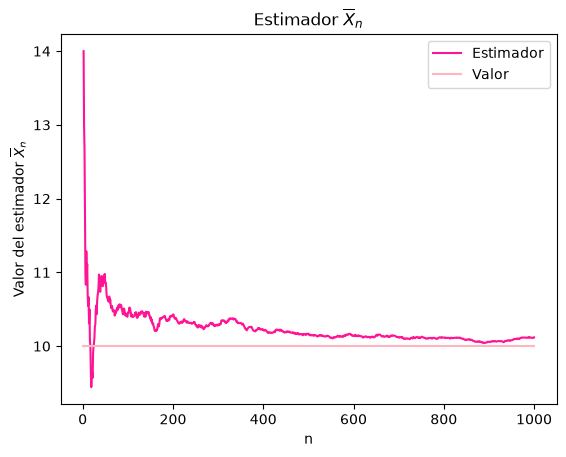

In [58]:
cantidad= np.arange(1, n +1)

nu= np.full(n,10)

plt.plot(cantidad, med_poiss, color="deeppink",label="Estimador")
plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor del estimador $\overline{X}_n$")
plt.title("Estimador $\overline{X}_n$")
plt.legend()
plt.savefig("results/estimador_media_muestral_poiss.png")
plt.show()

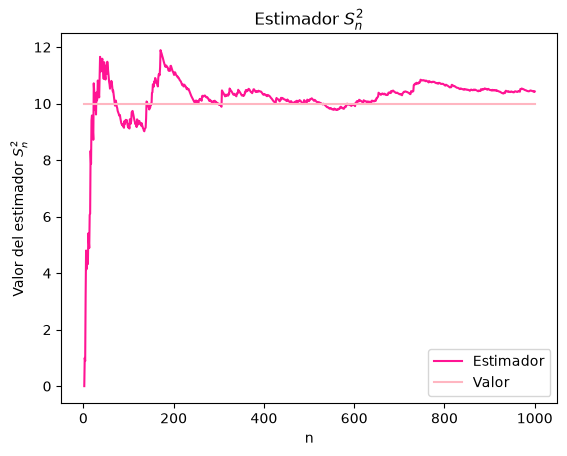

In [50]:
plt.plot(cantidad, var_poiss, color="deeppink",label="Estimador")
plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor del estimador $S_n^2$")
plt.title("Estimador $S_n^2$")
plt.legend()
plt.savefig("results/estimador_var_muestral_poiss.png")
plt.show()

Como ambos estiman el mismo parametro, $\nu$, los podemos comparar:

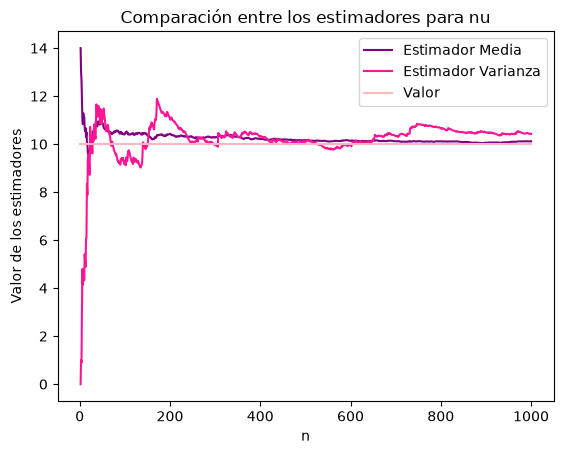

In [51]:
plt.plot(cantidad, med_poiss, color="purple",label="Estimador Media")
plt.plot(cantidad, var_poiss, color="deeppink",label="Estimador Varianza")
plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor de los estimadores")
plt.title("Comparación entre los estimadores para nu")
plt.legend()
plt.savefig("results/comparacion_estimadores_poisson.png")
plt.show()

Podemos ver que el estimador basado en el primer momento esta mucho mas cerca del valor a estimar. 

Para estimar la probabilidad del sistema vacío $\mathbb{P}(X=0)$ se proponen los siguientes estimadores: <br>
i) $\hat{g}_n^{(1)}=\exp(-\overline{X}_n)$, <br>
ii) $\hat{g}_n^{(2)}=\frac{1}{n} \sum_{i=1}^n\mathbf{1}_{X_i=0}$, <br>
iii) $\hat{g}_n^{(3)}=\exp(-S_n^2)$. <br>

In [62]:
g1 = np.exp(-med_poiss)

g2 = np.zeros(n)

for i in range(n):
    g2[i] = np.mean(rs_poisson[:i+1] == 0)

g3 = np.exp(-var_poiss)

valor_g_nu = np.full(n, np.exp(-10))


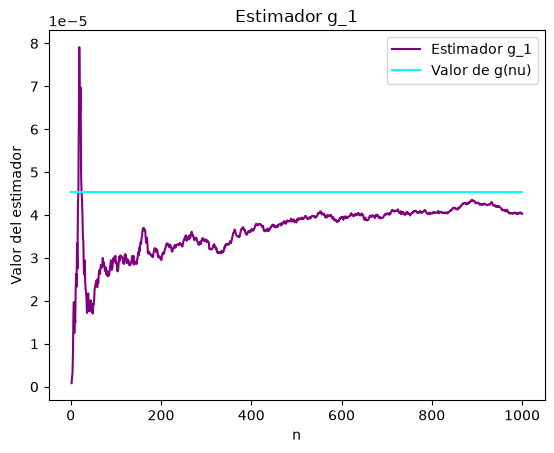

In [53]:
plt.plot(cantidad, g1, color="purple",label="Estimador g_1")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor del estimador")
plt.title("Estimador g_1")
plt.legend()
plt.savefig("results/estimador_g1.png")
plt.show()

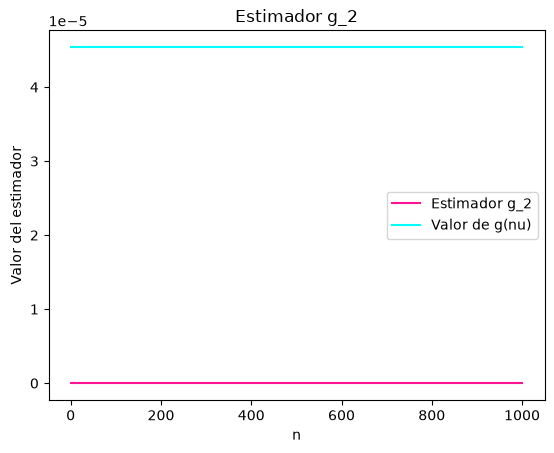

In [54]:
plt.plot(cantidad, g2, color="deeppink",label="Estimador g_2")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor del estimador")
plt.title("Estimador g_2")
plt.legend()
plt.savefig("results/estimador_g2.png")
plt.show()

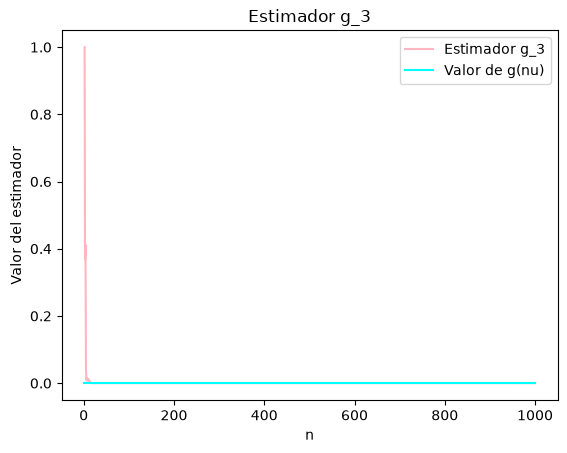

In [55]:
plt.plot(cantidad, g3, color="lightpink",label="Estimador g_3")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor del estimador")
plt.title("Estimador g_3")
plt.legend()
plt.savefig("results/estimador_g3.png")
plt.show()

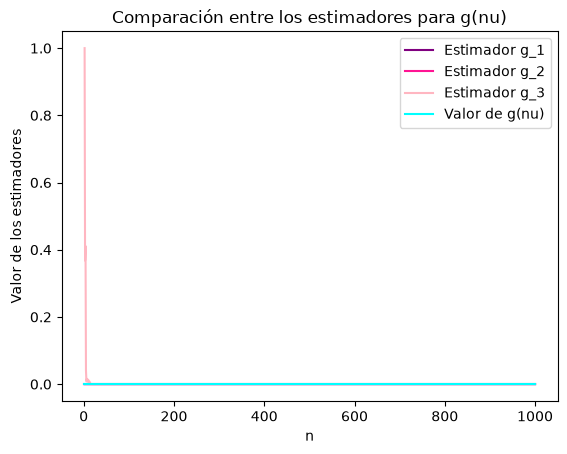

In [56]:
plt.plot(cantidad, g1, color="purple",label="Estimador g_1")
plt.plot(cantidad, g2, color="deeppink",label="Estimador g_2")
plt.plot(cantidad, g3, color="lightpink",label="Estimador g_3")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor de los estimadores")
plt.title("Comparación entre los estimadores para g(nu)")
plt.legend()
plt.savefig("results/comparacion_estimadores_g(nu).png")
plt.show()

En este caso, el estimador $\hat{g}^{(1)}$ tiene el mejor desempeño a la hora de estimar $g(\nu)$.

Ahora importemos el archivo datos_colas.csv y estudiemoslo para proponer un modelo parametrico:

In [57]:
df = pd.read_csv("data/raw/datos_cola.csv")

df["samples"]

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/datos_cola.csv'

In [ ]:

df["samples"].describe()

count    500.000000
mean       2.888000
std        1.642209
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        7.000000
Name: samples, dtype: float64

Sean $x_1,\dots,x_{500}$ los datos. Supongamos que existe una M.A.S. $X_1, \dots , X_{500}$ tal que $X_i(\omega)=x_i$. El objetivo es buscar la distribución de los $X_i$. Claramente estamos ante una distribución discreta, pues los datos son todos enteros, y en particular, enteros no negativos. 

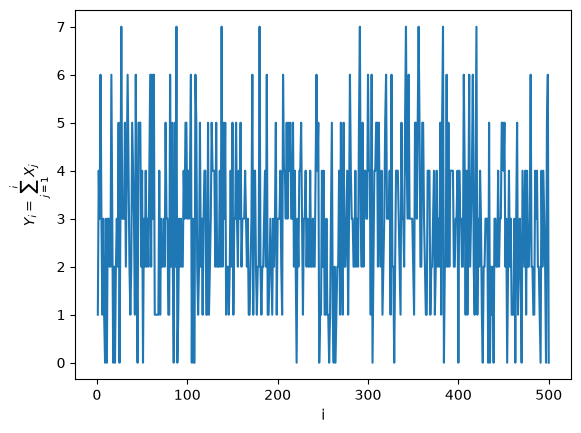

In [ ]:
x_colas = df["samples"].to_numpy()

m = len(x_colas)
i = np.arange(1, m + 1)

plt.plot(i, x_colas)
plt.xlabel("i")
plt.ylabel(r"$Y_i = \sum_{j=1}^i X_j$")
plt.show()

Text(0.5, 1.0, 'Distribución empírica de los datos')

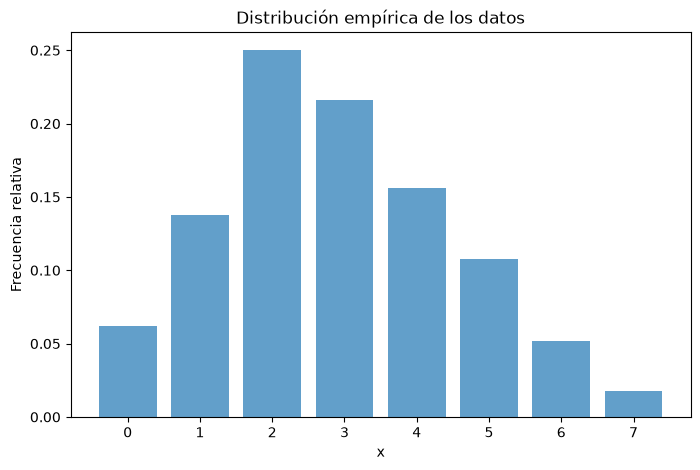

In [ ]:
x = df["samples"].values

valores, conteos = np.unique(x, return_counts=True)
frecuencias = conteos / len(x)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(valores, frecuencias, width=0.8, alpha=0.7, label="Empírico")
ax.set_xlabel("x")
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Distribución empírica de los datos")

Esto se parece a lo visto antes para la poisson. Antes de concluir testemos la relación media varianza. Si el valor es cercano a 1, entonces nos quedaremos con el modelo poisson, en caso de que no habria que buscar mas test, pero se podria probar con una binomial si es menor a uno y una binomial negativa o geometrica en el caso faltante. 

In [ ]:
media, var = x.mean(), x.var()
print(f"media/varianza = {media/var:.3f}")

media/varianza = 1.073


El modelo que mejor se ajusta es $X_i\sim Poiss(\nu)$, por los test realizados y por el transfondo teorico del modelamiento del fenomeno de colas. Estimemos $\nu$ con el estimador $\overline{X}_n$, pues era el estimador consistente e insesgado de mejor desempeño:

In [ ]:
nu = x.mean()

print("El valor de nu es " + str(nu))

El valor de nu es 2.888


Con ello podemos intentar estimar $g(\nu)$ con alguno de los estimadores antes propuestos. En este caso usaremos $\hat{g}_n^{(1)}= \exp(-\overline{X}_n)$ pues ya tenemos el valor del estimador para la media. 

In [ ]:
g_nu = np.exp(-nu)

print("El valor de g(nu) es "+ str(g_nu))

El valor de g(nu) es 0.05568747626326995
